In [5]:
import yaml
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [133]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']
tech_colors['rural ground heat pump'] = tech_colors['ground heat pump']
tech_colors['rural biomass boiler'] = tech_colors['biomass boiler']
tech_colors['urban central air heat pump'] = tech_colors['air heat pump']
tech_colors['urban central gas boiler'] = tech_colors['gas boiler']
tech_colors['urban central gas CHP'] = tech_colors['gas CHP']
tech_colors['urban central solid biomass CHP'] = tech_colors['biomass CHP']
tech_colors['urban decentral air heat pump'] = tech_colors['air heat pump']
tech_colors['urban decentral gas boiler'] = tech_colors['gas boiler']
tech_colors['urban decentral biomass boiler'] = tech_colors['biomass boiler']

In [82]:
filename = 'base_s_50__168H-T-H-B-I-A-dist1_2035_free_2525.nc'
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / filename
)

clusters = int(filename[7:].split('_')[0])

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_free_2525.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [132]:
ccc = pd.Index(n.links.carrier.unique())
ccc[ccc.str.contains('urban central')]

Index(['urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central solid biomass CHP',
       'urban central solid biomass CHP CC'],
      dtype='object')

In [127]:
# Find all links that connect to rural heat buses
rural_heat_buses = n.buses[n.buses.carrier == 'rural heat'].index
rural_heat_links = n.links[n.links.bus1.isin(rural_heat_buses)]
rural_heat_link_carriers = rural_heat_links.carrier.unique()
print("Carriers of links leading to rural heat buses:")
print(rural_heat_link_carriers)


Carriers of links leading to rural heat buses:
['rural air heat pump' 'rural biomass boiler' 'rural gas boiler'
 'rural ground heat pump']


In [ ]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat<100 industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture electricity',
       'agriculture heat', 'agriculture machinery electric',
       'agriculture machinery oil', 'rural heat', 'urban decentral heat'],
      dtype=object)

In [171]:
a = pd.Index(n.links.carrier.unique())
a[a.str.contains('<100')]

Index(['heat<100 industry solid biomass', 'heat<100 industry gas',
       'heat<100 industry industrial heat pump medium temperature',
       'heat<100 industry electric boiler steam'],
      dtype='object')

In [173]:
shown_techs = {
    'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas', 'Onshore Wind', 'Offshore Wind (AC)', 'nuclear', 'Reservoir & Dam', 'Solar'],
    'rural heat': ['rural gas boiler', 'rural ground heat pump', 'rural biomass boiler'],
    'urban decentral heat': ['urban decentral gas boiler', 'urban decentral air heat pump', 'urban decentral biomass boiler'],
    # 'urban central heat': ['urban central gas boiler', 'urban central air heat pump', 'urban central gas CHP', 'urban central solid biomass CHP']
    'urban central heat': ['urban central gas boiler', 'urban central air heat pump', 'urban central solid biomass CHP'],
    'heat<100 industry': [
        'heat<100 industry solid biomass',
        'heat<100 industry gas',
        'heat<100 industry industrial heat pump medium temperature',
        'heat<100 industry electric boiler steam',
    ],
    'heat100-200 industry': [
        'heat100-200 industry solid biomass',
        'heat100-200 industry gas',
        'heat100-200 industry industrial heat pump high temperature',
        'heat100-200 industry electric boiler steam',
    ],
    'heat200-500 industry': [
        'heat200-500 industry solid biomass',
        'heat200-500 industry gas',
        'heat200-500 industry hydrogen',
    ],
    'heat>500 industry': [
        'heat>500 industry gas',
        'heat>500 industry hydrogen',
    ],
}
fuels = {
    'Combined-Cycle Gas': 'gas',
    'Open-Cycle Gas': 'gas',
    'rural gas boiler': 'gas',
    'rural biomass boiler': 'solid biomass',
    'rural ground heat pump': 'AC',
    'urban decentral gas boiler': 'gas',
    'urban decentral air heat pump': 'AC',
    'urban decentral biomass boiler': 'solid biomass',
    'urban central gas boiler': 'gas',
    'urban central air heat pump': 'AC',
    'urban central gas CHP': 'gas',
    'urban central solid biomass CHP': 'solid biomass',
    'heat<100 industry solid biomass': 'solid biomass',
    'heat<100 industry gas': 'gas',
    'heat<100 industry industrial heat pump medium temperature': 'AC',
    'heat<100 industry electric boiler steam': 'AC',
    'heat100-200 industry solid biomass': 'solid biomass',
    'heat100-200 industry gas': 'gas',
    'heat100-200 industry industrial heat pump high temperature': 'AC',
    'heat100-200 industry electric boiler steam': 'AC',
    'heat200-500 industry solid biomass': 'solid biomass',
    'heat200-500 industry gas': 'gas',
    'heat200-500 industry hydrogen': 'H2',
    'heat>500 industry gas': 'gas',
    'heat>500 industry hydrogen': 'H2',
}
fixed_carriers = ['gas', 'solid biomass']
endogenous_carriers = ['AC', 'H2']

In [174]:
nodal_capex = n.statistics.capex(groupby=['bus', 'carrier'])
nodal_opex = n.statistics.opex(groupby=['bus', 'carrier'])

nodal_caps = n.statistics.optimal_capacity(groupby=['bus', 'carrier'])
nodal_supply = n.statistics.supply(groupby=['bus', 'carrier'])
wth = n.statistics.withdrawal(groupby=['bus', 'carrier'])

In [175]:
def to_ac_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

Combined-Cycle Gas
Open-Cycle Gas
Onshore Wind
Offshore Wind (AC)
nuclear
Reservoir & Dam
Solar
rural gas boiler
rural ground heat pump
rural biomass boiler
urban decentral gas boiler
urban decentral air heat pump
urban decentral biomass boiler
urban central gas boiler
49
urban central air heat pump
49
urban central solid biomass CHP
49
heat<100 industry solid biomass
heat<100 industry gas
heat<100 industry industrial heat pump medium temperature
heat<100 industry electric boiler steam
heat100-200 industry solid biomass
heat100-200 industry gas
heat100-200 industry industrial heat pump high temperature
heat100-200 industry electric boiler steam
heat200-500 industry solid biomass
heat200-500 industry gas
heat200-500 industry hydrogen
heat>500 industry gas
heat>500 industry hydrogen


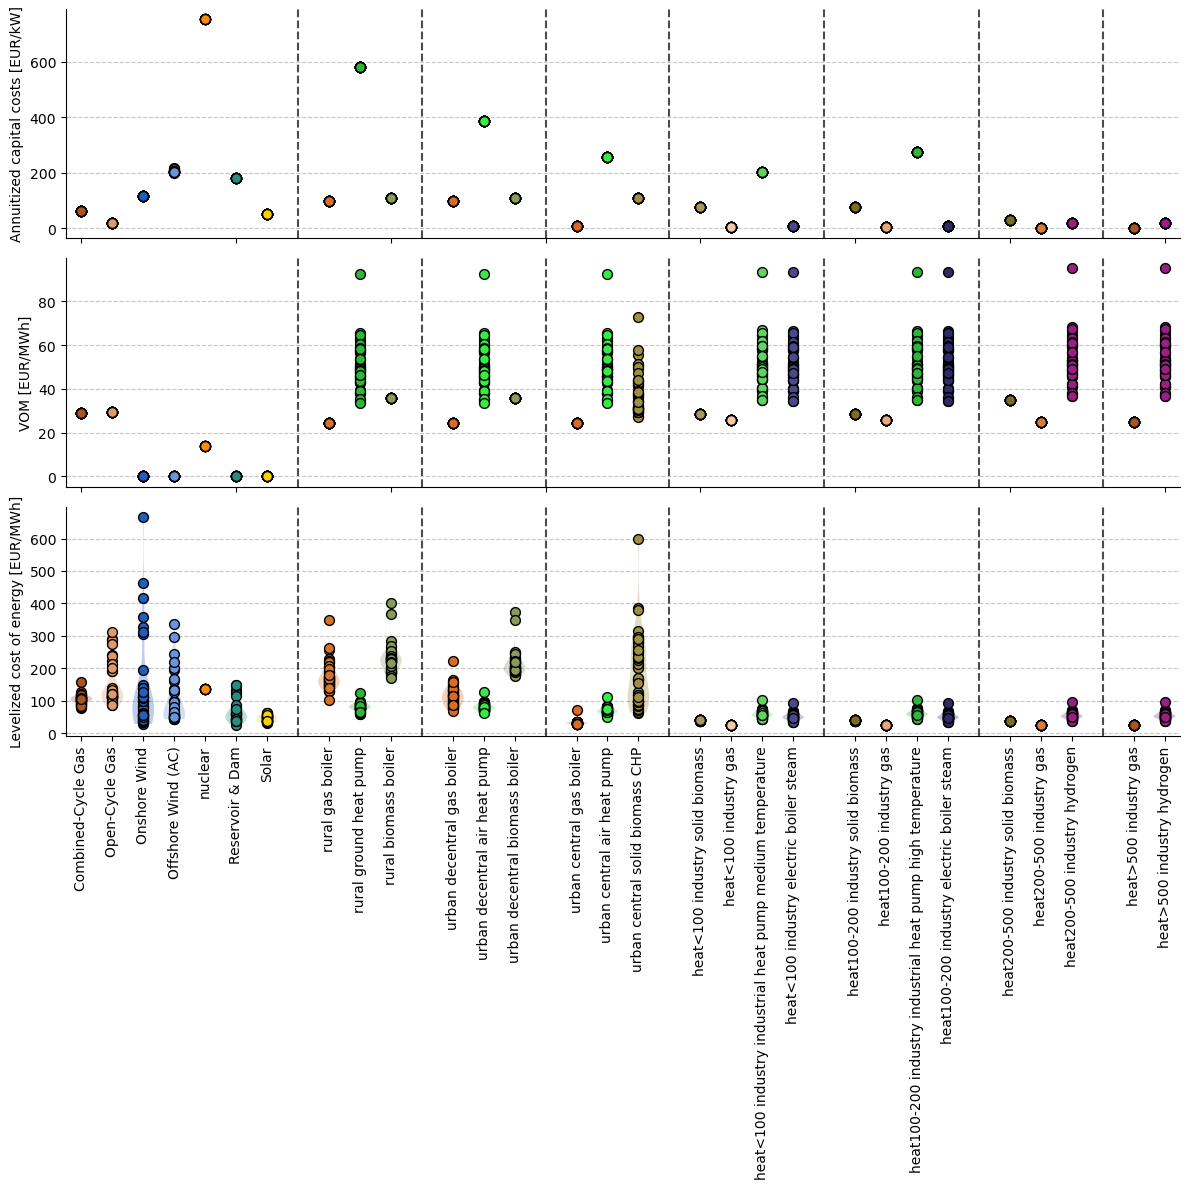

In [176]:
import seaborn as sns

idx = pd.IndexSlice

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

axs[0].set_ylabel('Annuitized capital costs [EUR/kW]')
axs[1].set_ylabel('VOM [EUR/MWh]')
axs[2].set_ylabel('Levelized cost of energy [EUR/MWh]')

xticklocs = list()
xticklabels = list()

inter_load_gap = 1
xloc_tracker = 0

for load, carriers in shown_techs.items():

    for carrier in carriers:

        print(carrier)

        total_cex = nodal_capex.loc[idx[:, :, carrier]].values[:clusters]
        cap = nodal_caps.loc[idx[:, :, carrier]].values[:clusters]

        cex = total_cex / cap * 1e-3

        axs[0].scatter(
            np.ones_like(cex) * xloc_tracker,
            cex,
            color=tech_colors[carrier],
            s=50,
            edgecolor='black',
        )

        total_ox = nodal_opex.loc[idx[:, :, carrier]].values[:clusters]

        if carrier in fuels:
            if fuels[carrier] in fixed_carriers:
                w = wth.loc[idx[:, :, carrier]].values[:clusters]
                fuel_cost = n.generators.loc[n.generators.carrier == fuels[carrier], 'marginal_cost'].mean()
            elif fuels[carrier] in endogenous_carriers:

                load = n.statistics.withdrawal(
                    groupby="bus",
                    aggregate_time=False,
                    bus_carrier='AC',
                    aggregate_across_components=True,
                ).T

                if not load.empty and load.sum().sum() > 0:
                    price = n.buses_t.marginal_price.loc[:, n.buses.carrier == 'AC']
                    price = price.reindex(columns=load.columns, fill_value=1)

                    weights = n.snapshot_weightings.generators
                    a = weights @ (load * price)
                    b = weights @ load
                    fuel_cost = (a / b).values[:clusters]

        else:
            fuel_cost = 0
            w = 1

        su = nodal_supply.loc[idx[:, :, carrier]].values[:clusters]

        # print(total_ox.shape)
        # print(total_cex.shape)
        # print(total_ox.shape)
        # print(su.shape)
        # Check if fuel_cost is iterable and has length
        fuel_cost_len = None
        try:
            fuel_cost_len = len(fuel_cost)
        except TypeError:
            pass  # fuel_cost is not iterable (e.g., scalar)
        
        if len(total_ox) != len(total_cex) or len(total_ox) != len(su) or (fuel_cost_len is not None and len(total_ox) != fuel_cost_len):

            length = min(len(total_cex), len(total_ox), len(su))
            total_cex = total_cex[:length]
            total_ox = total_ox[:length]
            su = su[:length]
            print(length)

            from typing import Iterable
            if isinstance(fuel_cost, Iterable):
                fuel_cost = fuel_cost[:length]

        ox = total_ox / su + fuel_cost

        axs[1].scatter(
            np.ones_like(ox) * xloc_tracker,
            ox,
            color=tech_colors[carrier],
            s=50,
            edgecolor='black',
        )
        lcoe = (total_cex + total_ox) / su + fuel_cost


        parts = axs[2].violinplot(
            [lcoe],
            positions=[xloc_tracker],
            widths=0.7,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )
        for pc in parts['bodies']:
            pc.set_facecolor(tech_colors[carrier])
            pc.set_alpha(0.3)
            pc.set_edgecolor('none')

        axs[2].scatter(
            np.ones_like(lcoe) * xloc_tracker,
            lcoe,
            color=tech_colors[carrier],
            s=50,
            edgecolor='black',
        )

        xticklocs.append(xloc_tracker)
        xticklabels.append(carrier)
        xloc_tracker += 1

    for ax in axs:
        ax.axvline(xloc_tracker + inter_load_gap / 2 - 0.5, color='black', linestyle='--', alpha=0.7)

    xloc_tracker += inter_load_gap


axs[-1].set_xticks(xticklocs)
axs[-1].set_xticklabels(xticklabels, rotation=90)

axs[0].set_xticklabels([])
axs[1].set_xticklabels([])

for ax in axs:
    ax.set_xlim(-0.5, xloc_tracker - 0.5 - inter_load_gap)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()